In [25]:
import numpy as np
import matplotlib.pyplot as plt
import geocat.viz as gv
import pandas as pd
from scipy import stats
from scipy.optimize import brentq

df = pd.read_parquet("C:\\Users\\Dongwei Chen\\Desktop\\W_Taylor\\caig_model_eval_25N_107W.parquet")
obs = df['CONUS404']
df.head()
#timeStemp = df['time']
#print(timeStemp)

,time,CONUS404,MLP,EBM,EBMregion,LR
0,2022-01-01 00:00:00,2.040816,9.302568,5.895028,3.561842,2.119738
1,2022-01-01 01:00:00,0.000000,13.376979,6.089458,3.587100,2.271362
2,2022-01-01 02:00:00,6.122449,16.556227,5.970848,3.294773,2.620974
3,2022-01-01 03:00:00,0.000000,22.961033,6.050785,4.024079,2.251962
4,2022-01-01 04:00:00,20.408163,22.895885,8.161668,3.791601,3.417434


In [26]:

Corr = []
prediction_std =[]

####MLP
corr = np.corrcoef(obs, df['MLP'])[0,1]
fitted_std = np.std(df['MLP'], ddof=0)
Corr.append(corr)
prediction_std.append(fitted_std)

######EBM
corr = np.corrcoef(obs, df['EBM'])[0,1]
fitted_std = np.std(df['EBM'], ddof=0)
Corr.append(corr)
prediction_std.append(fitted_std)


######EBMregion
corr = np.corrcoef(obs, df['EBMregion'])[0,1]
fitted_std = np.std(df['EBMregion'], ddof=0)
Corr.append(corr)
prediction_std.append(fitted_std)

######LR
corr = np.corrcoef(obs, df['LR'])[0,1]
fitted_std = np.std(df['LR'], ddof=0)
Corr.append(corr)
prediction_std.append(fitted_std)


######Reference
Corr.append(1)
prediction_std.append(np.std(obs, ddof=0))
print(Corr)
print(prediction_std)

[0.7465320267905686, 0.4711462583414239, 0.525381754954685, 0.4661585873455637, 1]
[5.717052936553955, 3.7634063219641805, 3.942108399624325, 1.7416439034659352, 7.644760702458033]


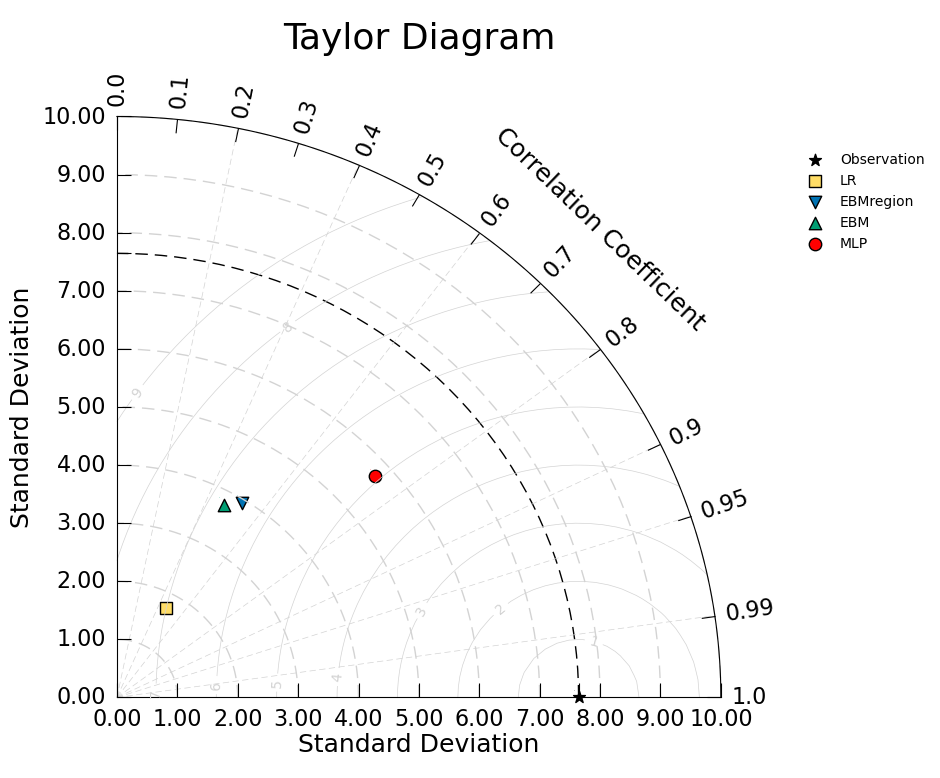

In [33]:
color_1 = (255/255, 0/255, 0/255)     # Pure Red
color_2  = (  0/255, 158/255, 115/255)   # Teal
color_3 = (0/255, 114/255, 178/255)   # Scientific Blue 
color_4  = (255/255, 221/255, 102/255)   # Soft Yellow
color_5  = (148/255,   0/255, 211/255)   # Dark Violet

color_6  = ( 86/255, 180/255, 233/255)   # Sky Blue
color_7  = (230/255, 159/255,   0/255)   # Orange Yellow
color_8 = (102/255, 51/255, 153/255)  # Deep Purple
color_9 = (139/255, 69/255, 19/255)   # Saddle Brown
color_10 = (180/255, 30/255, 90/255)   # Deep Rose
ground_truth_std = np.std(obs, ddof=0)

std_range_tuple = (0, 10)
#std_val_list = np.array([0, 0.5,1, 1.5,2,2.5,3,3.5,4,4.5,5,5.5, 6, 6.5, 7, 7.5, 8])
std_val_list = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10], dtype=float)

## Create basic figure and Taylor Diagram instance:
fig = plt.figure(figsize=(8, 8))

taylor = gv.TaylorDiagram( refstd=ground_truth_std
                         , fig=fig
                         , label=''
                         , std_range=std_range_tuple
                         , std_level=np.insert(std_val_list, np.searchsorted(std_val_list, ground_truth_std), ground_truth_std)
                         )
ax = plt.gca()

## Draw diagonal dashed lines from origin to correlation values
## Also enforces proper X-Y ratio
taylor.add_xgrid(np.array([0.2, 0.4, 0.6, 0.8, 0.9, 0.95, 0.99]))
taylor.add_ygrid(std_val_list)

taylor.add_model_set( [prediction_std[0]]
                    , [Corr[0]]
                    , label='MLP'
                    , annotate_on=True
                    , fontsize=0
                    # , xytext=(-5, 10)
                    , color=color_1
                    , marker='o'
                    , facecolors=color_1
                    , edgecolors='k'
                    , linewidth=1
                    , s=80
                    )

taylor.add_model_set( [prediction_std[1]]
                    , [Corr[1]]
                    , label='EBM'
                    , annotate_on=True
                    , fontsize=0
                    # , xytext=(-5, 10)
                    , color=color_2
                    , marker='^'
                    , facecolors=color_2
                    , edgecolors='k'
                    , linewidth=1
                    # , linestyle='--'
                    , s=80
                    )

taylor.add_model_set( [prediction_std[2]]
                    , [Corr[2]]
                    , label='EBMregion'
                    , annotate_on=True
                    , fontsize=0
                    # , xytext=(-5, 10)
                    , color=color_3
                    , marker='v'
                    , facecolors=color_3
                    , edgecolors='k'
                    , linewidth=1
                    , s=80
                    )

taylor.add_model_set( [prediction_std[3]]
                    , [Corr[3]]
                    , label='LR'
                    , annotate_on=True
                    , fontsize=0
                    # , xytext=(-5, 10)
                    , color=color_4
                    , marker='s'
                    , facecolors=color_4
                    , edgecolors='k'
                    , linewidth=1 
                    , s=80
                    )

taylor.add_model_set( [ground_truth_std]
                    , [1]
                    , label='Observation'
                    , annotate_on=True
                    , fontsize=0
                    # , xytext=(-5, 10)
                    , color='black'
                    , marker='*'
                    , facecolors='black'
                    , edgecolors='k'
                    , linewidth=1 
                    , s=80
                    )
#gv.util.set_axes_limits_and_ticks(ax, xlim=[0,2])

# taylor.add_model_name(['MLP', 'EBM', 'LR'], fontsize=16)

## Add figure title
plt.title("Taylor Diagram", size=26, pad=45)

taylor._ax.axis["left"].label.set_text("Standard Deviation")
taylor._ax.axis["right"].label.set_text("Standard Deviation")
taylor._ax.axis["top"].label.set_text("Correlation Coefficient")
taylor._ax.axis["left"].label.set_fontsize(18)
taylor._ax.axis["top"].label.set_fontsize(18)
taylor._ax.axis["right"].label.set_fontsize(18)


#taylor.add_legend(fontsize=10, loc='upper right')
taylor.add_legend(
    fontsize=10,
    loc='upper left',
    bbox_to_anchor=(1.05, 1)
)
## Add constant centered 2-Wasserstein difference contours.
crg = taylor.add_contours( levels=np.arange(0,10,1)
                         , colors='lightgrey'
                         , linewidths=0.5      
                         ).clabel()
# crg.clabel()

plt.savefig('Model_Taylor_Diagram.pdf', dpi=300, bbox_inches='tight')

In [28]:
x = np.asarray(obs)
n = len(x)
u = (np.arange(1, n + 1) - 0.5) / n

x_sorted = np.sort(x)
x_centered = x_sorted - np.mean(x)


def centered_w2_distance(x_centered, q):
    q_centered = q - np.mean(q)
    return np.sqrt(np.mean((x_centered - q_centered) ** 2))


def quantile_corr(x_centered, q):
    q_centered = q - np.mean(q)
    return np.mean(x_centered * q_centered) / (
        np.std(x_centered, ddof=0) * np.std(q_centered, ddof=0)
    )


# --------------------------------------------------
# Compute centered W2 and quantile correlation
# --------------------------------------------------

#####MLP
Centered_W_2 = []
Quantile_Corr = []
prediction_std =[]
w2c = centered_w2_distance(x_centered, df['MLP'])
qcorr = quantile_corr(x_centered, df['MLP'])
fitted_std = np.std(df['MLP'], ddof=0)
Centered_W_2.append(w2c)
Quantile_Corr.append(qcorr)
prediction_std.append(fitted_std)

######EBM
w2c = centered_w2_distance(x_centered, df['EBM'])
qcorr = quantile_corr(x_centered, df['EBM'])
fitted_std = np.std(df['EBM'], ddof=0)
Centered_W_2.append(w2c)
Quantile_Corr.append(qcorr)
prediction_std.append(fitted_std)


######EBMregion
w2c = centered_w2_distance(x_centered, df['EBMregion'])
qcorr = quantile_corr(x_centered, df['EBMregion'])
fitted_std = np.std(df['EBMregion'], ddof=0)
Centered_W_2.append(w2c)
Quantile_Corr.append(qcorr)
prediction_std.append(fitted_std)

######LR
w2c = centered_w2_distance(x_centered, df['LR'])
qcorr = quantile_corr(x_centered, df['LR'])
fitted_std = np.std(df['LR'], ddof=0)
Centered_W_2.append(w2c)
Quantile_Corr.append(qcorr)
prediction_std.append(fitted_std)


######Reference
Centered_W_2.append(0)
Quantile_Corr.append(1)
prediction_std.append(np.std(obs, ddof=0))
print(Centered_W_2)
print(Quantile_Corr)
print(prediction_std)


# --------------------------------------------------
# Verify the law of cosines
#
# W_{2,c}^2
# =
# sigma_x^2 + sigma_q^2
# - 2 sigma_x sigma_q rho_q
# --------------------------------------------------

sigma_x = prediction_std[-1]

for i in range(len(prediction_std)):

    sigma_q = prediction_std[i]
    rho_q = Quantile_Corr[i]
    w2c = Centered_W_2[i]

    lhs = w2c**2

    rhs = (
        sigma_x**2
        + sigma_q**2
        - 2 * sigma_x * sigma_q * rho_q
    )

    print(f"LHS = W2_c^2      = {lhs:.10f}")
    print(f"RHS law cosine    = {rhs:.10f}")
    print(f"Difference        = {abs(lhs-rhs):.2e}")
    print("-" * 60)

[9.624068510439221, 8.494635257076538, 8.615464271864868, 7.757033572207904, 0]
[-0.017109282619336502, 0.007764336109906207, -0.004042274096245431, 0.048973850165107184, 1]
[5.717052936553955, 3.7634063219641805, 3.942108399624325, 1.7416439034659352, 7.644760702458033]
LHS = W2_c^2      = 92.6226946936
RHS law cosine    = 92.6226000358
Difference        = 9.47e-05
------------------------------------------------------------
LHS = W2_c^2      = 72.1588281508
RHS law cosine    = 72.1588281508
Difference        = 2.76e-12
------------------------------------------------------------
LHS = W2_c^2      = 74.2262246198
RHS law cosine    = 74.2262246198
Difference        = 2.74e-12
------------------------------------------------------------
LHS = W2_c^2      = 60.1715698404
RHS law cosine    = 60.1715698404
Difference        = 2.69e-12
------------------------------------------------------------
LHS = W2_c^2      = 0.0000000000
RHS law cosine    = 0.0000000000
Difference        = 0.00e+00
-

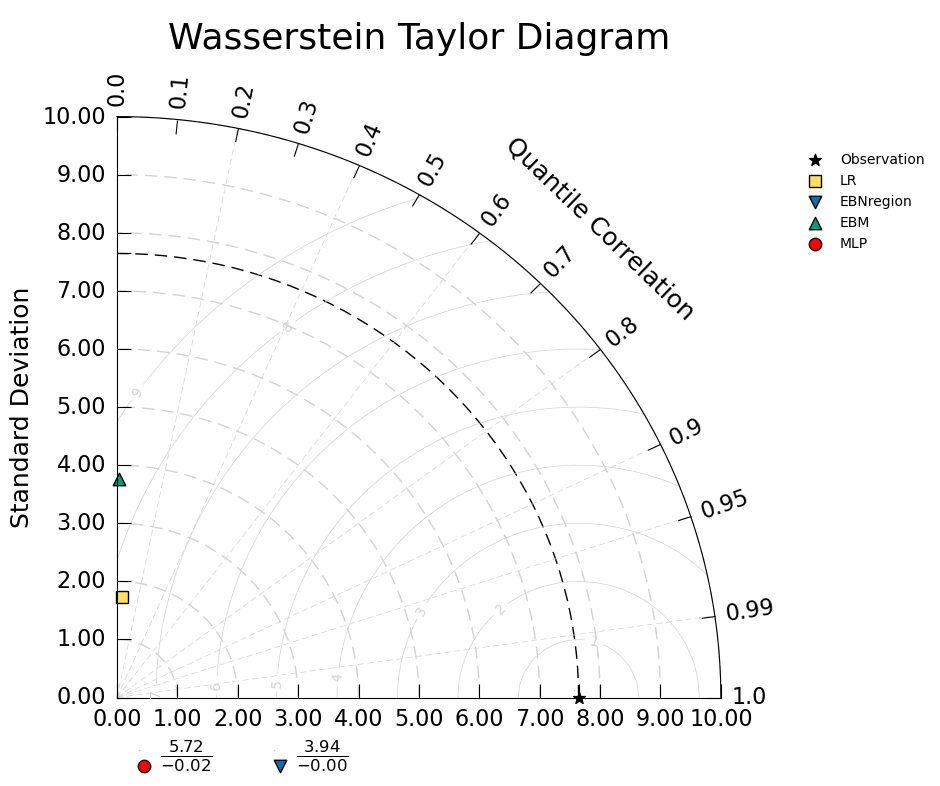

In [34]:
color_1 = (255/255, 0/255, 0/255)     # Pure Red
color_2  = (  0/255, 158/255, 115/255)   # Teal
color_3 = (0/255, 114/255, 178/255)   # Scientific Blue 
color_4  = (255/255, 221/255, 102/255)   # Soft Yellow
color_5  = (148/255,   0/255, 211/255)   # Dark Violet

color_6  = ( 86/255, 180/255, 233/255)   # Sky Blue
color_7  = (230/255, 159/255,   0/255)   # Orange Yellow
color_8 = (102/255, 51/255, 153/255)  # Deep Purple
color_9 = (139/255, 69/255, 19/255)   # Saddle Brown
color_10 = (180/255, 30/255, 90/255)   # Deep Rose
ground_truth_std = np.std(obs, ddof=0)

std_range_tuple = (0, 10)
std_val_list = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10], dtype=float)

## Create basic figure and Taylor Diagram instance:
fig = plt.figure(figsize=(8, 8))

taylor = gv.TaylorDiagram( refstd=ground_truth_std
                         , fig=fig
                         , label=''
                         , std_range=std_range_tuple
                         , std_level=np.insert(std_val_list, np.searchsorted(std_val_list, ground_truth_std), ground_truth_std)
                         )
ax = plt.gca()

## Draw diagonal dashed lines from origin to correlation values
## Also enforces proper X-Y ratio
taylor.add_xgrid(np.array([0.2, 0.4, 0.6, 0.8, 0.9, 0.95, 0.99]))
taylor.add_ygrid(std_val_list)

taylor.add_model_set( [prediction_std[0]]
                    , [Quantile_Corr[0]]
                    , label='MLP'
                    , annotate_on=True
                    , fontsize=0
                    # , xytext=(-5, 10)
                    , model_outlier_on=True  # plots models with negative correlations and/or standard deviations at bottom of diagram
                    , color=color_1
                    , marker='o'
                    , facecolors=color_1
                    , edgecolors='k'
                    , linewidth=1
                    , s=80
                    )

taylor.add_model_set( [prediction_std[1]]
                    , [Quantile_Corr[1]]
                    , label='EBM'
                    , annotate_on=True
                    , fontsize=0
                    # , xytext=(-5, 10)
                    , color=color_2
                    , marker='^'
                    , facecolors=color_2
                    , edgecolors='k'
                    , linewidth=1
                    # , linestyle='--'
                    , s=80
                    )

taylor.add_model_set( [prediction_std[2]]
                    , [Quantile_Corr[2]]
                    , label='EBNregion'
                    , annotate_on=True
                    , fontsize=0
                    # , xytext=(-5, 10)
                    , model_outlier_on=True  # plots models with negative correlations and/or standard deviations at bottom of diagram
                    , color=color_3
                    , marker='v'
                    , facecolors=color_3
                    , edgecolors='k'
                    , linewidth=1
                    , s=80
                    )
taylor.add_model_set( [prediction_std[3]]
                    , [Quantile_Corr[3]]
                    , label='LR'
                    , annotate_on=True
                    , fontsize=0
                    # , xytext=(-5, 10)
                    , color=color_4
                    , marker='s'
                    , facecolors=color_4
                    , edgecolors='k'
                    , linewidth=1 
                    , s=80
                    )

taylor.add_model_set( [ground_truth_std]
                    , [1]
                    , label='Observation'
                    , annotate_on=True
                    , fontsize=0
                    # , xytext=(-5, 10)
                    , color='black'
                    , marker='*'
                    , facecolors='black'
                    , edgecolors='k'
                    , linewidth=1 
                    , s=80
                    )
#gv.util.set_axes_limits_and_ticks(ax, xlim=[0,2])

# taylor.add_model_name(['MLP', 'EBM', 'LR'], fontsize=16)

## Add figure title
plt.title("Wasserstein Taylor Diagram", size=26, pad=45)

#taylor._ax.axis["left"].label.set_text("Standard Deviation")
taylor._ax.axis["right"].label.set_text("Standard Deviation")
taylor._ax.axis["top"].label.set_text("Quantile Correlation")
taylor._ax.axis["left"].label.set_fontsize(18)
taylor._ax.axis["top"].label.set_fontsize(18)
taylor._ax.axis["right"].label.set_fontsize(18)


#taylor.add_legend(fontsize=10, loc='upper right')
taylor.add_legend(
    fontsize=10,
    loc='upper left',
    bbox_to_anchor=(1.05, 1)
)
## Add constant centered 2-Wasserstein difference contours.
crg = taylor.add_contours( levels=np.arange(0,10,1)
                         , colors='lightgrey'
                         , linewidths=0.5      
                         ).clabel()
# crg.clabel()

plt.savefig('Wind_Taylor_Diagram.pdf', dpi=300, bbox_inches='tight')

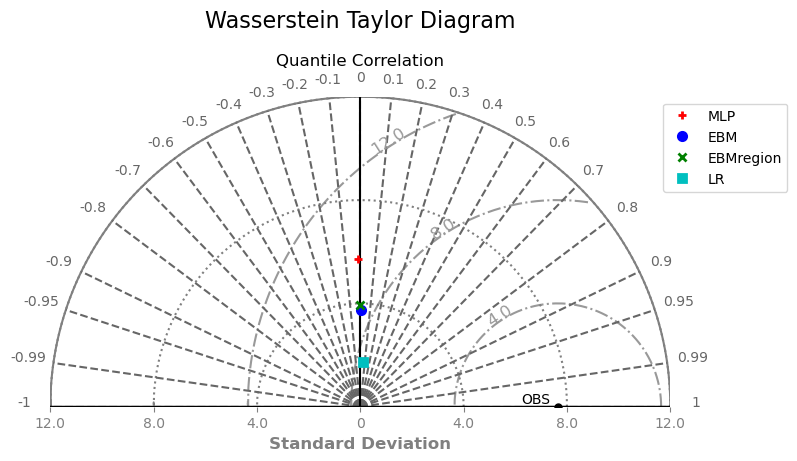

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import skill_metrics as sm

sdev = np.array([7.644760702458033, 5.717052936553955, 3.7634063219641805, 3.942108399624325, 1.7416439034659352])
crmsd = np.array([0, 9.624068510439221, 8.494635257076538, 8.615464271864868, 7.757033572207904])
ccoef = np.array([1, -0.017109282619336502, 0.007764336109906207, -0.004042274096245431, 0.048973850165107184])

labels = ["Observation", "MLP", "EBM", "EBMregion", "LR"]

plt.figure(figsize=(8, 8))

sm.taylor_diagram(
    sdev,
    crmsd,
    ccoef,
    markerLabel=labels,
    markerSize=6,
    #titleOBS='*',
    markerLegend='on',
    markerDisplayed='marker',
    #titleCOR='Quantile Correlation',
    #labelRMS='RMSE',
    titleRMS='off',
    titleCOR='off',
    checkStats='on',
    axismax=12,
    colCOR='0.4',
    colSTD='0.5',
    colRMS='0.6',
    styleCOR='--',
    styleSTD=':',
    styleRMS='-.'
)

sdev = np.array([7.644760702458033, 7.644760702458033])
crmsd = np.array([0, 0])
ccoef = np.array([1, 1])

label = ['Observation', 'OBS']
sm.taylor_diagram(sdev,crmsd,ccoef, overlay = 'on',
                      markerLabel = label, markerLabelColor = 'black',
                      markerColor = 'black')


plt.title(
    "Wasserstein Taylor Diagram",
    fontsize=16,
    pad=50
)
plt.text(
    0.5,
    1.1,
    'Quantile Correlation',
    transform=plt.gca().transAxes,
    ha='center',
    fontsize=12
)
#plt.title("Taylor Diagram with Negative Correlation")
plt.savefig('Model_Wasserstein_Taylor_Diagram.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
sm.taylor_diagram